In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits

In [4]:
digits = load_digits()

print(digits.data.shape)
print(digits.images.shape)
print(digits.target.shape)

(1797, 64)
(1797, 8, 8)
(1797,)


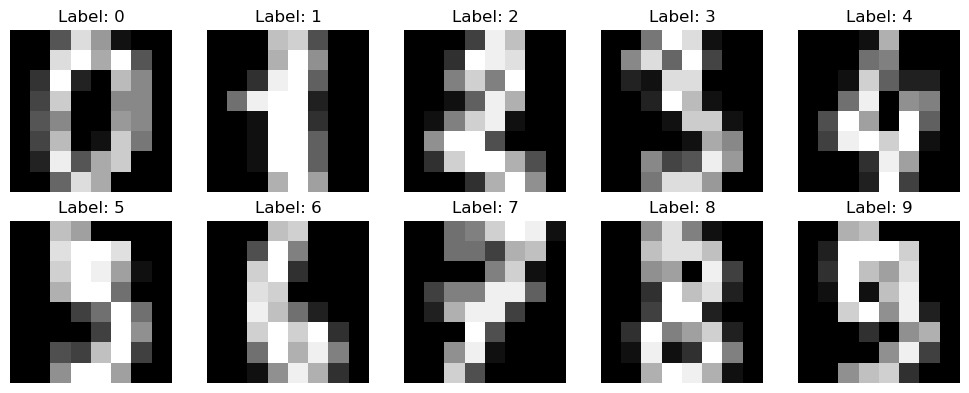

In [6]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(f"Label: {digits.target[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

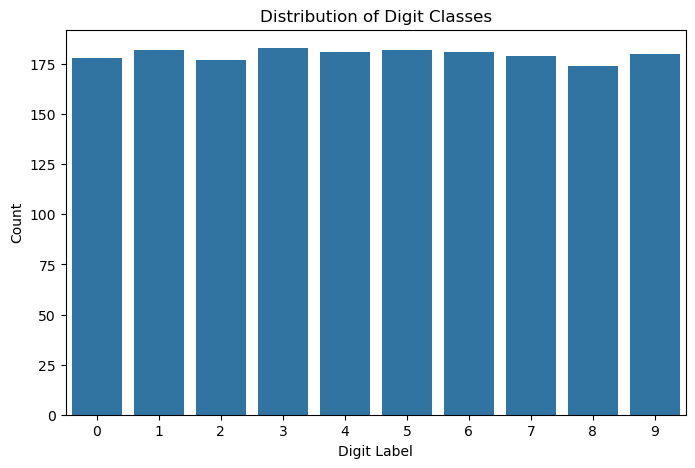

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(x=digits.target)

plt.title("Distribution of Digit Classes")
plt.xlabel("Digit Label")
plt.ylabel("Count")

plt.show()

In [10]:
print("Minimum pixel value:", digits.data.min())
print("Maximum pixel value:", digits.data.max())

Minimum pixel value: 0.0
Maximum pixel value: 16.0


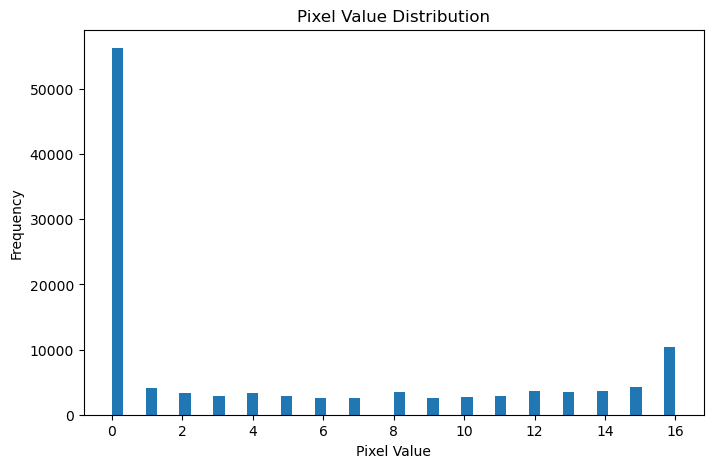

In [12]:
plt.figure(figsize=(8,5))

plt.hist(digits.data.flatten(), bins=50)

plt.title("Pixel Value Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

In [14]:
# Normalize pixel values

X = digits.data / 16.0

y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1797, 64)
y shape: (1797,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1437, 64)
(360, 64)
(1437,)
(360,)


In [22]:
import torch

# Convert to tensors

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Check shapes

print(X_train_tensor.shape)
print(X_test_tensor.shape)

print(y_train_tensor.shape)
print(y_test_tensor.shape)

torch.Size([1437, 64])
torch.Size([360, 64])
torch.Size([1437])
torch.Size([360])


In [20]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 10)
)

print(model)

Sequential(
  (0): Linear(in_features=64, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=10, bias=True)
)


In [24]:
import torch.optim as optim

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [28]:
for epoch in range(200):

    # Forward pass
    outputs = model(X_train_tensor)

    # Calculate loss
    loss = criterion(outputs, y_train_tensor)

    # Reset gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 2.0290725231170654
Epoch 20, Loss: 1.7662872076034546
Epoch 40, Loss: 1.4353690147399902
Epoch 60, Loss: 1.0987850427627563
Epoch 80, Loss: 0.8247276544570923
Epoch 100, Loss: 0.6304196119308472
Epoch 120, Loss: 0.49807512760162354
Epoch 140, Loss: 0.4055738151073456
Epoch 160, Loss: 0.3376413583755493
Epoch 180, Loss: 0.28575384616851807


In [30]:
with torch.no_grad():

    outputs_test = model(X_test_tensor)

    _, predicted = torch.max(outputs_test, 1)

print(predicted[:20])

tensor([6, 9, 3, 7, 2, 1, 5, 2, 5, 3, 1, 4, 4, 0, 4, 2, 3, 7, 8, 8])


In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test_tensor.numpy(),
    predicted.numpy()
)

print("Accuracy:", accuracy)

Accuracy: 0.9416666666666667


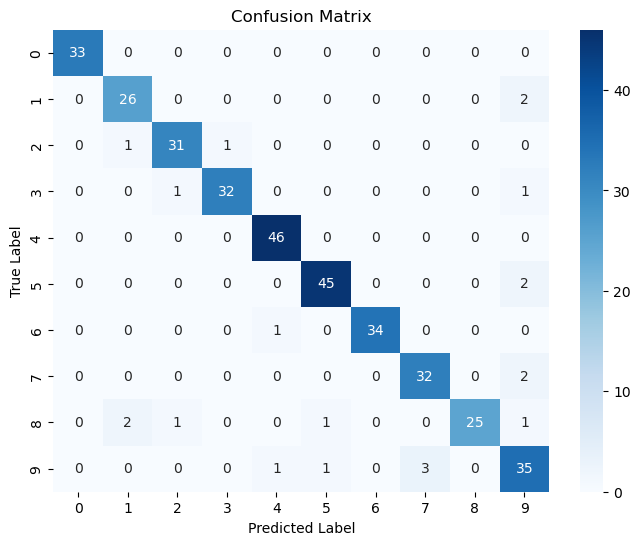

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_tensor.numpy(),
    predicted.numpy()
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [36]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_tensor.numpy(),
        predicted.numpy()
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.90      0.93      0.91        28
           2       0.94      0.94      0.94        33
           3       0.97      0.94      0.96        34
           4       0.96      1.00      0.98        46
           5       0.96      0.96      0.96        47
           6       1.00      0.97      0.99        35
           7       0.91      0.94      0.93        34
           8       1.00      0.83      0.91        30
           9       0.81      0.88      0.84        40

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



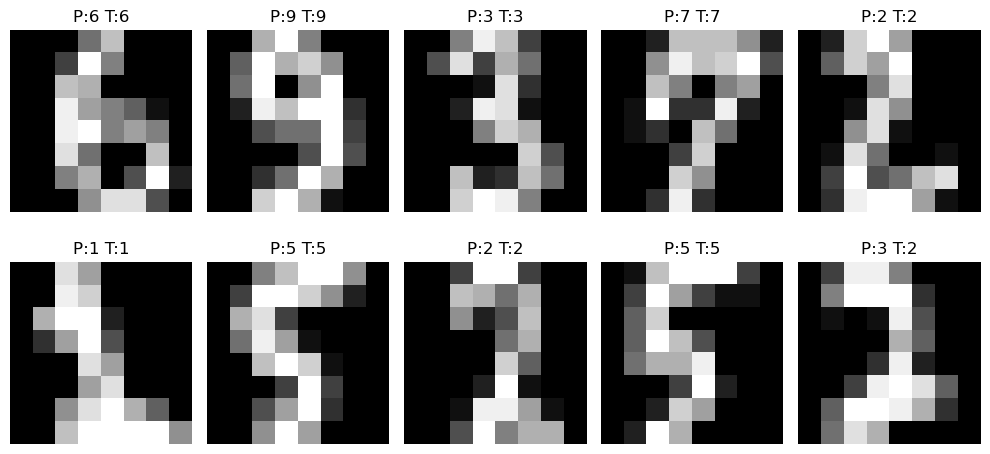

In [38]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[i].reshape(8,8),
        cmap="gray"
    )

    plt.title(
        f"P:{predicted[i].item()} T:{y_test[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()